# 1. Import Dependencies and Setup

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import cv2
import imghdr
from matplotlib import pyplot as plt
from tensorflow.keras import models, layers, metrics

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
for gpu in tf.config.experimental.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

Num GPUs Available:  0


# 2. Preprocess Data

In [3]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']
for image_class in os.listdir(os.path.join('data')):
    for image in os.listdir(os.path.join('data', image_class)):
        image_path = os.path.join('data', image_class, image)
        try:
            img = cv2.imread(image_path)
            typ = imghdr.what(image_path)
            if typ not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            print(e)
            # os.remove(image_path)
print('Complete!')

Issue with image data\chicken\.ipynb_checkpoints
[Errno 13] Permission denied: 'data\\chicken\\.ipynb_checkpoints'
Issue with image data\steak\.ipynb_checkpoints
[Errno 13] Permission denied: 'data\\steak\\.ipynb_checkpoints'
Complete!


# 3. Load and Scale Data

Found 2433 files belonging to 5 classes.


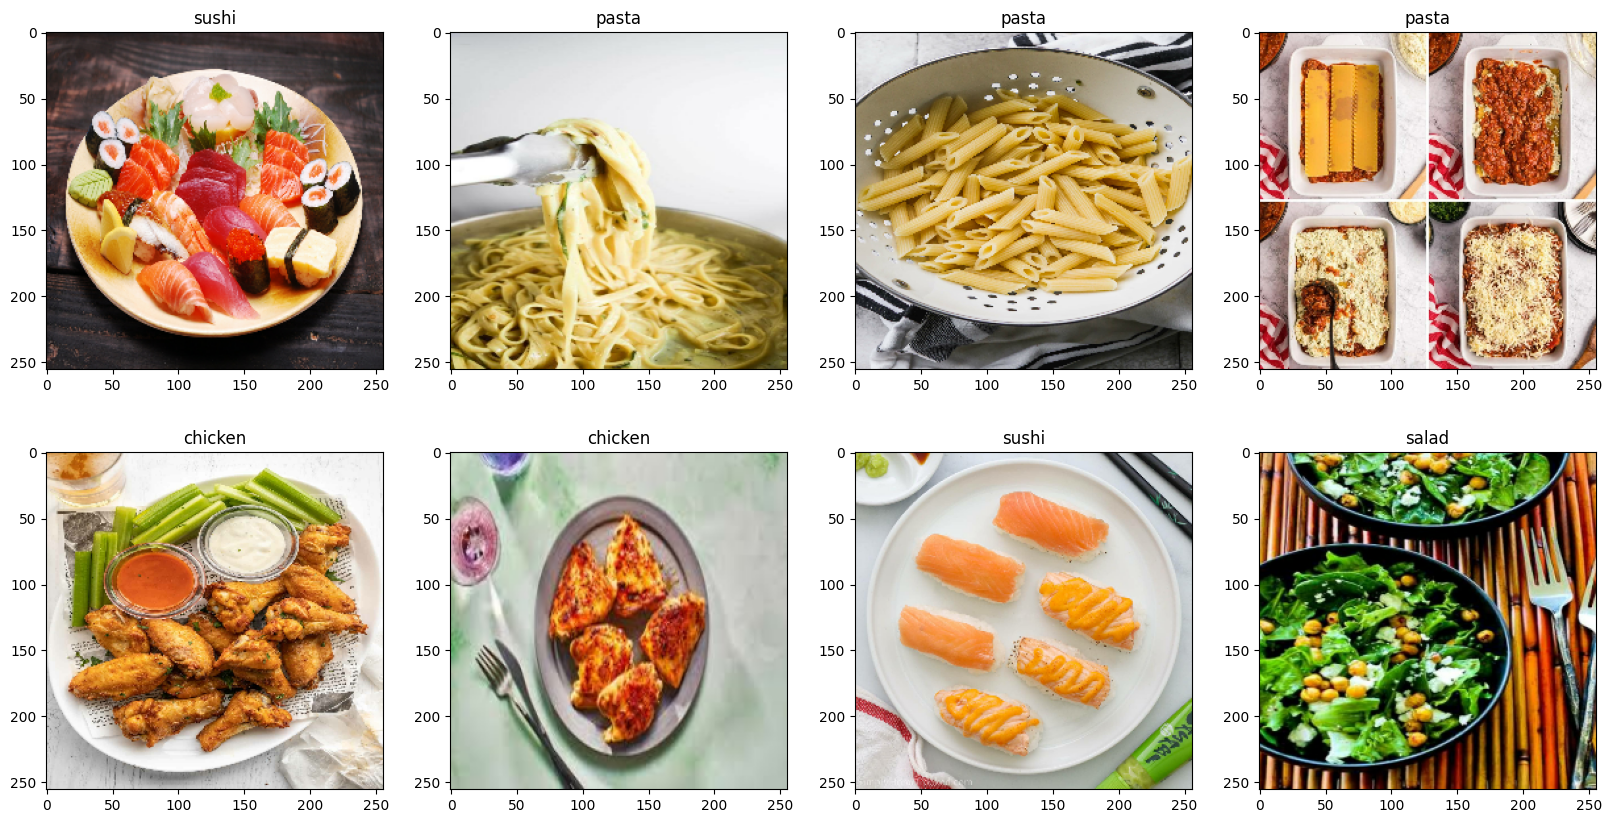

In [4]:
data = tf.keras.utils.image_dataset_from_directory('data', seed=1)
iter = data.as_numpy_iterator()
# batch object has the image at batch[0] in numpy RGB array form, and the corresponding label at batch[1]
batch = iter.next()
labels =  os.listdir('data')

# visualization
fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(20,10))
for i, img in enumerate(batch[0][:8]):
    ax[i//4][i%4].imshow(img.astype(int))
    ax[i//4][i%4].title.set_text(labels[batch[1][i]])
plt.show()

# scale each RGB value to [0,1]
data = data.map(lambda x,y: (x/255, y))

# 4. Split Data

In [5]:
batch_size = len(data)
train_size = int(batch_size *.7)
val_size = int(batch_size *.2)
test_size = int(batch_size *.1)
while(train_size + val_size + test_size != batch_size):
    test_size += 1
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 5. Train Model

In [6]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), 1, activation='relu', input_shape=(256,256,3), padding='same'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3, 3), 1, activation='relu'))
model.add(layers.Conv2D(128, (1, 1), 1, activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(256, (3, 3), 1, activation='relu'))
model.add(layers.Conv2D(256, (1, 1), 1, activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(len(labels), activation='softmax'))

In [7]:
model.compile('adam', loss=tf.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 128)     36992     
                                                                 
 conv2d_2 (Conv2D)           (None, 126, 126, 128)     16512     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 63, 63, 128)      0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 256)       2

In [9]:
cb = tf.keras.callbacks.TensorBoard(log_dir='logs')
hist = model.fit(train, epochs=5, validation_data=val, callbacks=cb)

Epoch 1/5
53/53 [==============================] - 468s 9s/step - loss: 1.1014 - accuracy: 0.5607 - val_loss: 0.9801 - val_accuracy: 0.6333
Epoch 2/5
53/53 [==============================] - 473s 9s/step - loss: 0.8119 - accuracy: 0.6775 - val_loss: 0.9166 - val_accuracy: 0.6500
Epoch 3/5
53/53 [==============================] - 462s 9s/step - loss: 0.6732 - accuracy: 0.7406 - val_loss: 0.7730 - val_accuracy: 0.6938
Epoch 4/5
53/53 [==============================] - 470s 9s/step - loss: 0.5053 - accuracy: 0.8054 - val_loss: 0.6757 - val_accuracy: 0.7312
Epoch 5/5
53/53 [==============================] - 461s 9s/step - loss: 0.3700 - accuracy: 0.8626 - val_loss: 0.7860 - val_accuracy: 0.7542


In [24]:
#model.save(os.path.join('models', 'model_87.h5'))

# Visualizations!!!

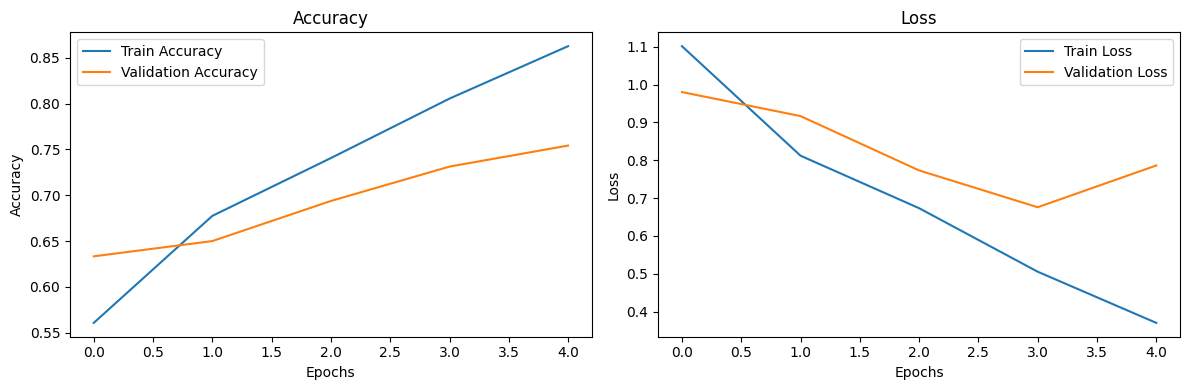

In [15]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(hist)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report
test_images = []
test_labels = []

for batch in test.as_numpy_iterator():
    X, y = batch
    test_images.append(X)
    test_labels.append(y)

# Convert list to numpy arrays
test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert softmax outputs to class labels

# Generate confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(test_labels, y_pred_classes, target_names=labels))

# 6. Testing

1/1 [==============================] - 0s 392ms/step
Accuracy is : 0.8715953307392996


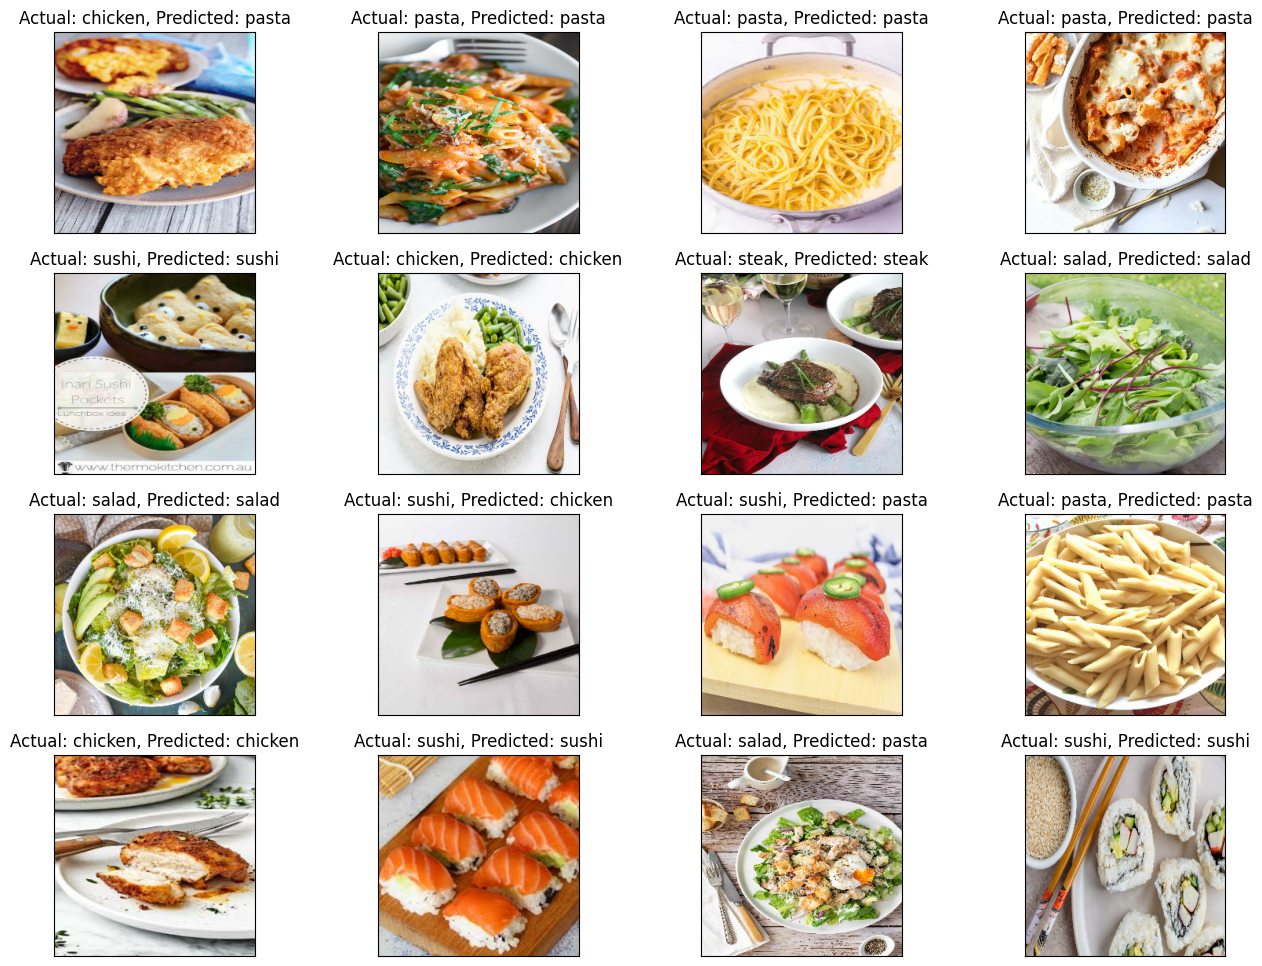

In [27]:
model = models.load_model(os.path.join('models', 'model_87.h5'))

fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(16,12))

df = pd.DataFrame()
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    num_images = min(16, X.shape[0])  # Ensure we don't exceed available images
    for i in range(num_images):
        ax[i//4][i%4].imshow(X[i])
        ax[i//4][i%4].title.set_text('Actual: ' + labels[y[i]] + ', Predicted: ' + labels[np.argmax(yhat[i])])
        ax[i//4][i%4].get_xaxis().set_ticks([])
        ax[i//4][i%4].get_yaxis().set_ticks([])
    
    temp = pd.DataFrame({'actual' : y.tolist(), 'prediction' : yhat.tolist()})
    temp['prediction'] = temp['prediction'].apply(np.argmax)
    
    df = pd.concat([df, temp], axis=0)
true_count = df[df.actual == df.prediction].shape[0]
acc = true_count / df.shape[0]
print('Accuracy is :', acc)